# Load Packages and Data

In [136]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters, run_suggest_pitches_bulk
import warnings
import pandas as pd

from biomech import compute_euclidean_distances

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [135]:
import importlib
import pitch_suggestions

importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [88]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

# Identify Pitch Opportunities

In [89]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [137]:
b_bello = suggest_pitches(
    target_pitcher='Bello, Brayan',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [138]:
b_bello['status']

'ok'

In [139]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2025
release_pos_x               -1.657082
release_pos_z                5.323063
release_extension            6.342714
arm_angle                   32.793504
n                                2697
max_velo                    95.301591
max_spin                  2479.262411
pri_fb                             SI
fb_pfx_x                    -1.408565
fb_n                            943.0
pri_fb_cd                           0
active_spin_fastball             80.8
FB_type                            FF
Name: 3714, dtype: object

In [140]:
b_bello['comps']

,comp_pitcher,comp_year,distance
0,"Pop, Zach",2021,0.269251
1,"Bolton, Cody",2023,0.306450
2,"Kolek, Stephen",2024,0.317300
3,"Kochanowicz, Jack",2025,0.320015
4,"Moronta, Reyes",2022,0.332231
...,...,...,...
310,"Francis, Bowden",2023,1.484341
311,"Bird, Jake",2024,1.485625
312,"Hembree, Heath",2021,1.487102
313,"Paredes, Enoli",2021,1.494888


In [141]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(48, 16)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,cluster_label,biomech_distance,sim_weight
3,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.556191,ST,1,0.612139,CU,1.135869,0.880382
4,"Scherzer, Max",2021,CU,76.863538,1.120650,-0.661625,277,2821,0.098192,1.810144,ST,1,0.525505,CU,1.168811,0.855570
5,"Darvish, Yu",2023,CU,72.575490,0.997157,-1.292745,102,2208,0.046196,2.959243,ST,1,0.570373,CU,0.946487,1.056537
6,"Mikolas, Miles",2024,CU,76.587580,0.664395,-1.182548,314,2697,0.116426,2.245386,ST,1,0.698466,CU,1.306019,0.765685
7,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.740989,ST,1,0.736015,CU,1.443101,0.692952


In [142]:
b_bello['suggestions']

,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,CU,47,78.4,0.94,-1.07,1.94,78.6,0.94,-1.06,0.649,"CS, CU, KC","Antone, Tejay, Avila, Pedro, Barlow, Scott, Ba..."


In [143]:
b_bello['target_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Bello, Brayan",2025,CH,88.787073,-1.336869,0.377049,410
1,"Bello, Brayan",2025,FC,88.241371,0.072411,0.215721,423
2,"Bello, Brayan",2025,FF,95.075980,-0.638393,1.126201,408
3,"Bello, Brayan",2025,SI,95.301591,-1.408565,0.471697,943
4,"Bello, Brayan",2025,ST,85.676608,0.825887,-0.265263,513


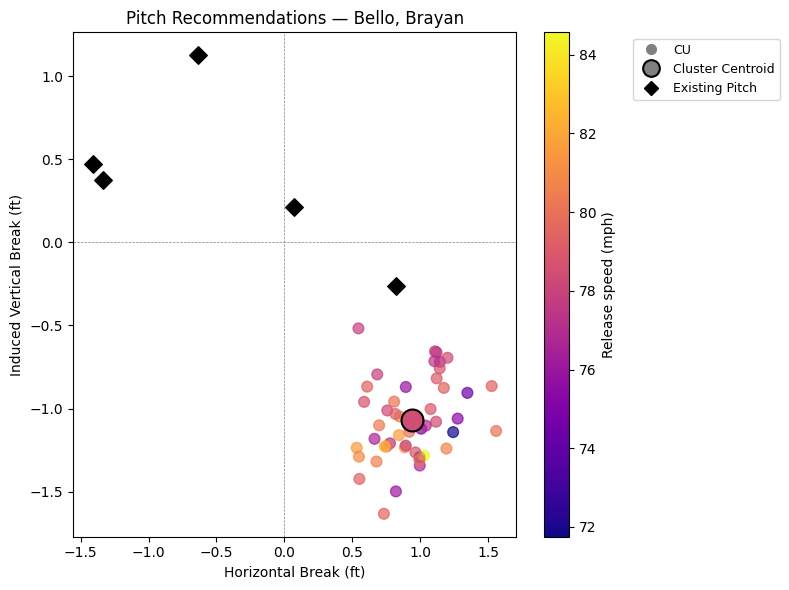

In [144]:
plot_pitch_clusters(b_bello)

## Bulk runs

In [145]:
l_bulk = run_suggest_pitches_bulk(pitcher_summ_l, pitch_type_summ, 
                                  min_pitches=20,
                                  biomech_distance_threshold=1.5,  
                                  novelty_distance_threshold=1.5,  
                                  min_comp_usage_pct=0.01)

In [146]:
l_bulk[0]

,target_pitcher,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,"Hill, Rich",SL,4,82.2,-0.54,-0.17,1.69,82.1,-0.55,-0.17,0.429,"CU, SL","Alexander, Scott, Alexander, Tyler, Garrett, B..."
1,"Hill, Rich",CU,2,80.8,-0.18,-0.51,1.93,80.8,-0.18,-0.50,0.647,"CU, KC","Freeland, Kyle, Zimmermann, Bruce"
2,"Wilson, Justin",CU,66,78.7,-0.77,-0.70,2.30,78.4,-0.76,-0.73,0.731,"CU, KC, SL, ST, SV","Abad, Fernando, Abbott, Andrew, Allard, Kolby,..."
3,"Wilson, Justin",SI,10,93.0,1.34,0.86,1.59,92.4,1.33,0.89,0.837,"CH, SI","Banuelos, Manny, Borucki, Ryan, Jay, Tyler, Ma..."
4,"Kershaw, Clayton",ST,6,79.0,-1.09,-0.06,1.83,78.9,-1.09,-0.06,0.575,"SL, ST, SV","Allen, Logan, Davidson, Tucker, Guenther, Sean..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,"Cameron, Noah",SI,3,90.5,1.42,0.64,1.65,90.4,1.42,0.64,0.871,"CH, SI","Anderson, Tyler, Beeks, Jalen, Mayza, Tim"
236,"Messick, Parker",CU,13,78.3,-0.19,-0.80,1.64,78.4,-0.17,-0.75,0.553,"CU, KC","Anderson, Tyler, Basso, Brady, Freeland, Kyle,..."
237,"Early, Connelly",CH,5,83.9,1.15,0.86,1.58,84.0,1.15,0.86,0.528,CH,"Corbin, Patrick, García, Jarlín, Hall, DL, Lyn..."
238,"Farris, Mitch",CU,34,75.4,-0.85,-0.95,2.03,75.1,-0.84,-0.97,0.725,"CU, KC, ST","Allard, Kolby, Benjamin, Wes, Bermúdez, Jonath..."


In [147]:
l_bulk[1]

,target_pitcher,status,n_comps,n_suggestions
0,"Hill, Rich",ok,33,2
1,"Wilson, Justin",ok,115,2
2,"Kershaw, Clayton",ok,28,2
3,"Miley, Wade",ok,142,1
4,"Quintana, Jose",ok,102,2
...,...,...,...,...
202,"Sommers, Drew",no_comps,0,0
203,"Gibson, Cade",no_novel_pitches,113,0
204,"Early, Connelly",ok,62,1
205,"Farris, Mitch",ok,81,2
